# CS 460 Final Project: Swarm Behavior Classification

**Student:** Anthony Marrs  
**Course:** CSCI 460 / CS 460 Intro. to Applied Machine Learning  
**Dataset:** Swarm Behavior Dataset  

This notebook is organized to match the final project requirements: dataset loading, exploratory data analysis, preprocessing, baseline model training, hyperparameter tuning, final evaluation, confusion matrices, and result visualizations.

## 1. Import Libraries

This section imports the libraries used for data processing, visualization, preprocessing, modeling, tuning, and evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Install/import XGBoost in Colab if needed
try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Load the Three Swarm Behavior CSV Files

Upload the three CSV files to Google Colab first:

- `Aligned.csv`
- `Flocking.csv`
- `Grouped.csv`

The `low_memory=False` setting helps prevent mixed-type warnings when pandas reads a large CSV file.

In [ ]:
aligned = pd.read_csv("Aligned.csv", low_memory=False)
flocking = pd.read_csv("Flocking.csv", low_memory=False)
grouped = pd.read_csv("Grouped.csv", low_memory=False)

print("Aligned:", aligned.shape)
print("Flocking:", flocking.shape)
print("Grouped:", grouped.shape)

Aligned: (24016, 2401)
Flocking: (24016, 2401)
Grouped: (24016, 2401)


## 3. Clean Column Names and Verify Column Alignment

Before merging the datasets, strip extra spaces from column names and confirm that all three files have matching columns.

In [ ]:
aligned.columns = aligned.columns.str.strip()
flocking.columns = flocking.columns.str.strip()
grouped.columns = grouped.columns.str.strip()

print("Aligned matches Flocking:", aligned.columns.equals(flocking.columns))
print("Aligned matches Grouped:", aligned.columns.equals(grouped.columns))

# If the output is False, inspect the differences:
print("Columns in Aligned but not Flocking:", set(aligned.columns) - set(flocking.columns))
print("Columns in Flocking but not Aligned:", set(flocking.columns) - set(aligned.columns))

Aligned matches Flocking: True
Aligned matches Grouped: True
Columns in Aligned but not Flocking: set()
Columns in Flocking but not Aligned: set()


## 4. Merge the Datasets

The three files are combined into one dataset. Each row represents one swarm simulation instance, and `Class` is the target variable.

In [ ]:
df = pd.concat([aligned, flocking, grouped], ignore_index=True)

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (72048, 2401)


,x1,y1,xVel1,yVel1,xA1,yA1,xS1,yS1,xC1,yC1,...,yVel200,xA200,yA200,xS200,yS200,xC200,yC200,nAC200,nS200,Class
0,-1414.14,-535.22,-17.88,-7.23,0.00,0.0,0.00,0.00,0.00,0.00,...,-16.85,0.0,0.00,0.0,0.0,0.00,0.00,29,0,0
1,-1412.93,597.54,-13.55,-5.48,0.00,0.0,0.00,0.00,0.00,0.00,...,-12.09,0.0,0.00,0.0,0.0,0.00,0.00,44,0,0
2,-1407.38,70.72,-14.37,-5.81,0.00,0.0,0.00,0.00,0.00,0.00,...,-16.20,0.0,0.00,0.0,0.0,0.00,0.00,40,0,0
3,-1407.0,-759.80,-7.59,-1.27,-0.98,-0.2,0.00,0.00,0.91,0.41,...,2.99,-1.0,-0.07,0.0,0.0,-0.52,0.86,3,0,1
4,-1406.36,698.39,-16.54,-6.95,-1.00,0.0,-944.07,-396.62,0.00,0.00,...,-12.61,0.0,-1.00,0.0,0.0,0.00,0.00,13,0,0


# Exploratory Data Analysis (EDA)

EDA should happen **after loading/merging the data** and **before preprocessing/model training**. This section explores dataset size, target balance, missing values, feature distributions, and correlations.

## 5. Dataset Overview

This gives a first look at the dataset structure, column names, and data types.

In [ ]:
print("Dataset shape:", df.shape)
print("Number of columns:", len(df.columns))
print("First 10 columns:", list(df.columns[:10]))
print("Last 10 columns:", list(df.columns[-10:]))

df.info()

Dataset shape: (72048, 2401)
Number of columns: 2401
First 10 columns: ['x1', 'y1', 'xVel1', 'yVel1', 'xA1', 'yA1', 'xS1', 'yS1', 'xC1', 'yC1']
Last 10 columns: ['yVel200', 'xA200', 'yA200', 'xS200', 'yS200', 'xC200', 'yC200', 'nAC200', 'nS200', 'Class']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72048 entries, 0 to 72047
Columns: 2401 entries, x1 to Class
dtypes: float64(1999), int64(401), object(1)
memory usage: 1.3+ GB


## 6. Target Variable / Class Distribution

This checks whether the classification problem is balanced or imbalanced. Because the class counts are not perfectly equal, F1-score will be especially important later.

Class
0    43529
1    28519
Name: count, dtype: int64


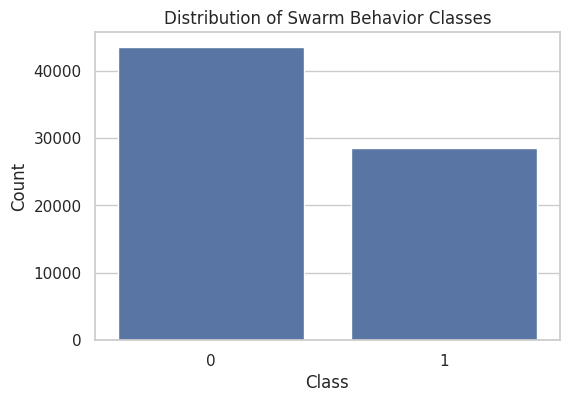

In [ ]:
class_counts = df["Class"].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Class")
plt.title("Distribution of Swarm Behavior Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## 7. Missing Value Check

This checks for missing values before formal preprocessing. Some blank strings may not show as missing until the feature columns are converted to numeric values, so this section checks both raw and numeric-converted versions.

In [ ]:
print("Raw missing values in full dataframe:", df.isna().sum().sum())

X_eda = df.drop("Class", axis=1).copy()
X_eda = X_eda.apply(pd.to_numeric, errors="coerce")

print("Missing/invalid values after numeric conversion:", X_eda.isna().sum().sum())

Raw missing values in full dataframe: 0
Missing/invalid values after numeric conversion: 1


## 8. Summary Statistics

Because the dataset has thousands of features, the full `describe()` table is large. This section shows the full summary table and then a smaller summary for the first few columns.

In [ ]:
df.describe()

,y1,xVel1,yVel1,xA1,yA1,xS1,yS1,xC1,yC1,nAC1,...,yVel200,xA200,yA200,xS200,yS200,xC200,yC200,nAC200,nS200,Class
count,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,...,72048.00000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000
mean,-73.077114,-0.737331,0.041984,-0.148090,0.151028,-1.217209,-0.835799,-0.035581,0.075808,19.029772,...,0.06571,-0.125927,0.127226,-1.660584,-0.095942,-0.017049,0.085548,26.258744,2.147360,0.395833
std,572.544168,6.445160,7.374782,0.377023,0.590211,27.762558,21.669453,0.558139,0.626962,23.232914,...,7.70935,0.380751,0.571113,77.200092,7.362678,0.551916,0.613362,33.996529,7.532625,0.489032
min,-1012.180000,-18.590000,-18.410000,-1.000000,-1.000000,-944.070000,-847.910000,-2.680000,-2.680000,0.000000,...,-18.44000,-1.040000,-1.000000,-4079.230000,-370.240000,-2.680000,-2.680000,0.000000,0.000000,0.000000
25%,-609.352500,-5.520000,-5.710000,-0.230000,-0.010000,0.000000,0.000000,-0.040000,-0.020000,3.000000,...,-5.62000,-0.190000,0.000000,0.000000,0.000000,-0.072500,0.000000,2.000000,0.000000,0.000000
50%,-156.685000,-0.460000,-1.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,...,-0.74000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000
75%,424.445000,3.820000,7.310000,0.000000,0.940000,0.000000,0.000000,0.000000,0.020000,31.000000,...,7.48000,0.000000,0.540000,0.000000,0.000000,0.000000,0.020000,35.000000,1.000000,1.000000
max,1015.800000,18.470000,18.630000,1.000000,1.040000,68.560000,234.740000,2.680000,2.680000,157.000000,...,18.53000,1.000000,1.040000,255.990000,68.940000,2.680000,2.680000,142.000000,65.000000,1.000000


In [ ]:
X_eda.iloc[:, :10].describe()

,x1,y1,xVel1,yVel1,xA1,yA1,xS1,yS1,xC1,yC1
count,72047.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000,72048.000000
mean,108.300480,-73.077114,-0.737331,0.041984,-0.148090,0.151028,-1.217209,-0.835799,-0.035581,0.075808
std,842.165182,572.544168,6.445160,7.374782,0.377023,0.590211,27.762558,21.669453,0.558139,0.626962
min,-1414.140000,-1012.180000,-18.590000,-18.410000,-1.000000,-1.000000,-944.070000,-847.910000,-2.680000,-2.680000
25%,-539.665000,-609.352500,-5.520000,-5.710000,-0.230000,-0.010000,0.000000,0.000000,-0.040000,-0.020000
50%,156.010000,-156.685000,-0.460000,-1.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,898.135000,424.445000,3.820000,7.310000,0.000000,0.940000,0.000000,0.000000,0.000000,0.020000
max,1406.080000,1015.800000,18.470000,18.630000,1.000000,1.040000,68.560000,234.740000,2.680000,2.680000


## 9. Sample Feature Distributions

Only a subset of features is plotted because the dataset has about 2400 feature columns. These histograms help show the spread and shape of selected swarm features.

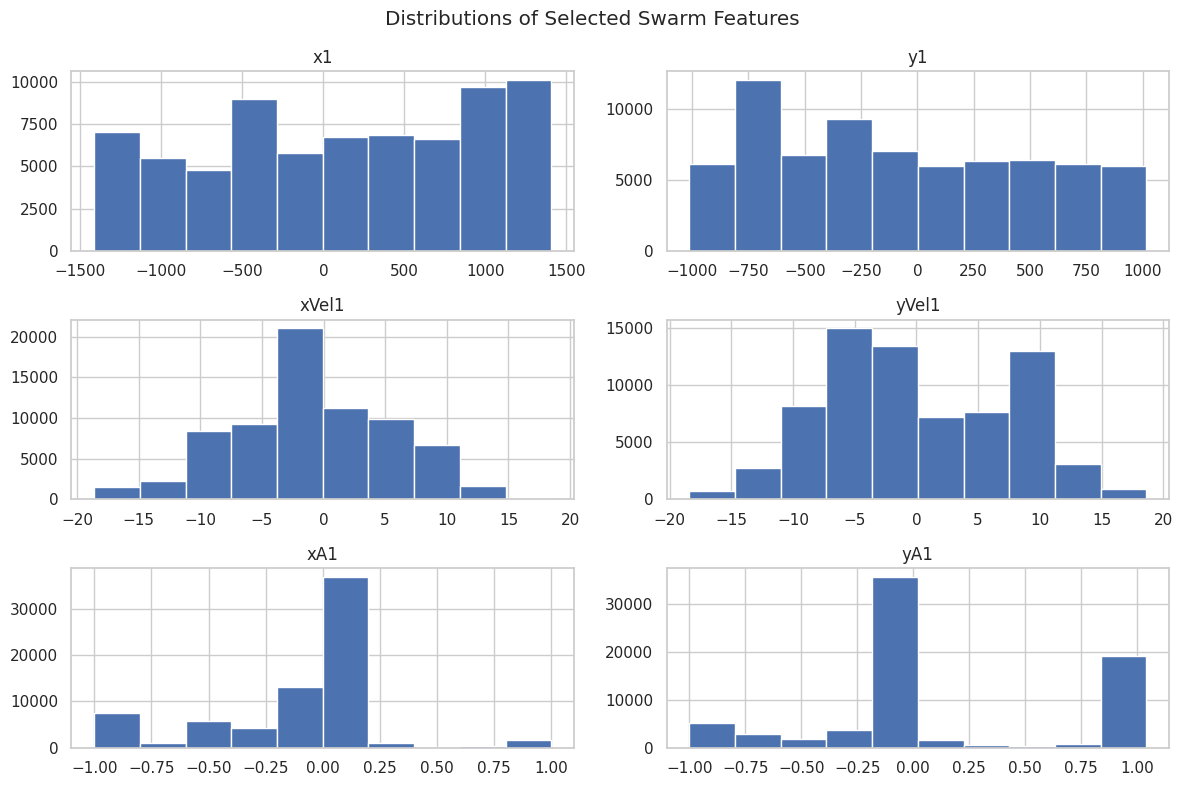

In [ ]:
sample_features = X_eda.iloc[:, :6].fillna(X_eda.mean()).columns

X_eda[sample_features].fillna(X_eda[sample_features].mean()).hist(figsize=(12, 8))
plt.suptitle("Distributions of Selected Swarm Features")
plt.tight_layout()
plt.show()

## 10. Correlation Heatmap for Selected Features

A heatmap of all 2400 features would be unreadable, so this heatmap uses the first 20 feature columns. This helps identify whether some features are correlated or redundant.

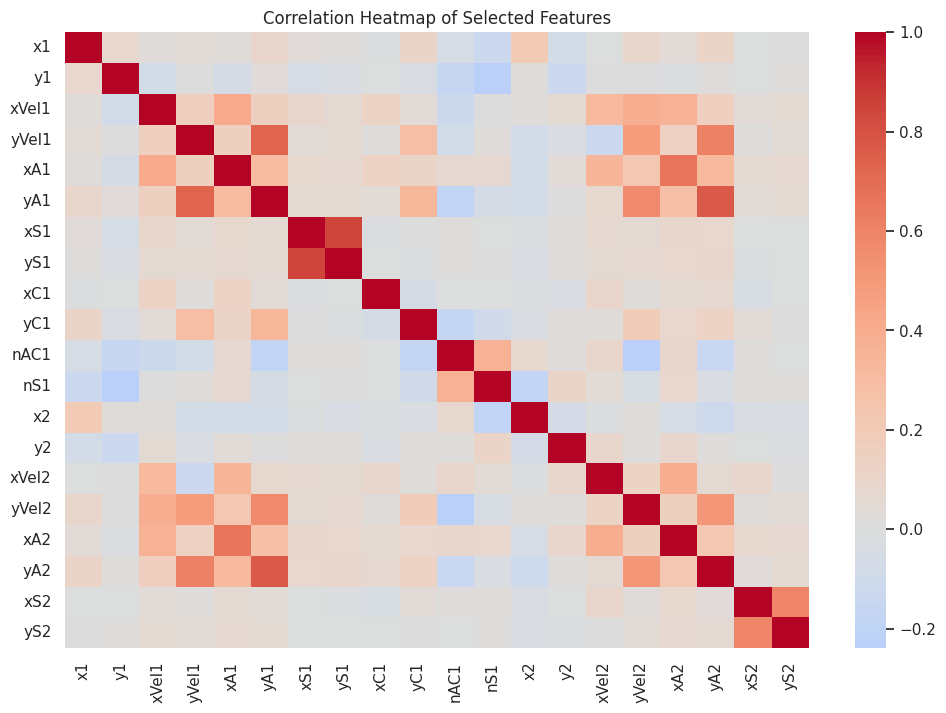

In [ ]:
subset = X_eda.iloc[:, :20].copy()
subset = subset.fillna(subset.mean())

plt.figure(figsize=(12, 8))
sns.heatmap(subset.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Selected Features")
plt.show()

## 11. EDA Summary Notes

Use these points in the report:

- The dataset is a binary classification problem because the target variable is `Class`.
- The dataset is high-dimensional, with approximately 2400 predictor features.
- The class distribution is somewhat imbalanced, so F1-score is more informative than accuracy alone.
- Some values need numeric conversion and missing-value handling before scaling and modeling.
- PCA is justified because the feature space is very large.

# Data Preprocessing

This section prepares the data for machine learning by separating features and target, converting all features to numeric values, handling missing values, splitting the data, scaling, and applying PCA.

## 12. Separate Features and Target

`X` contains all predictor variables. `y` contains the class label.

In [ ]:
X = df.drop("Class", axis=1).copy()
y = df["Class"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class labels:", sorted(y.unique()))

X shape: (72048, 2400)
y shape: (72048,)
Class labels: [np.int64(0), np.int64(1)]


## 13. Convert Features to Numeric and Handle Missing Values

Blank strings or invalid values are converted to `NaN`, then missing values are replaced with the mean of each column.

In [ ]:
X = X.apply(pd.to_numeric, errors="coerce")
print("Missing values before imputation:", X.isna().sum().sum())

X = X.fillna(X.mean())
print("Missing values after imputation:", X.isna().sum().sum())
print("Feature dtypes:", X.dtypes.unique())

Missing values before imputation: 1
Missing values after imputation: 0
Feature dtypes: [dtype('float64') dtype('int64')]


## 14. Train/Test Split

A held-out test set is created before model tuning. Stratification preserves the class distribution in both training and test sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train: (57638, 2400)
X_test: (14410, 2400)
y_train distribution:
 Class
0    0.604167
1    0.395833
Name: proportion, dtype: float64
y_test distribution:
 Class
0    0.604164
1    0.395836
Name: proportion, dtype: float64


## 15. Feature Scaling

Scaling is required for distance-based and margin-based models such as KNN, Logistic Regression, and SVM. Tree-based models do not require scaling.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (57638, 2400)
Scaled test shape: (14410, 2400)


## 16. PCA Dimensionality Reduction

The dataset has approximately 2400 features. PCA reduces the feature space to 50 principal components to improve computational efficiency and reduce redundancy.

In [ ]:
pca = PCA(n_components=50, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA training shape:", X_train_pca.shape)
print("PCA test shape:", X_test_pca.shape)
print("Total explained variance by 50 components:", pca.explained_variance_ratio_.sum())

PCA training shape: (57638, 50)
PCA test shape: (14410, 50)
Total explained variance by 50 components: 0.554113583670512


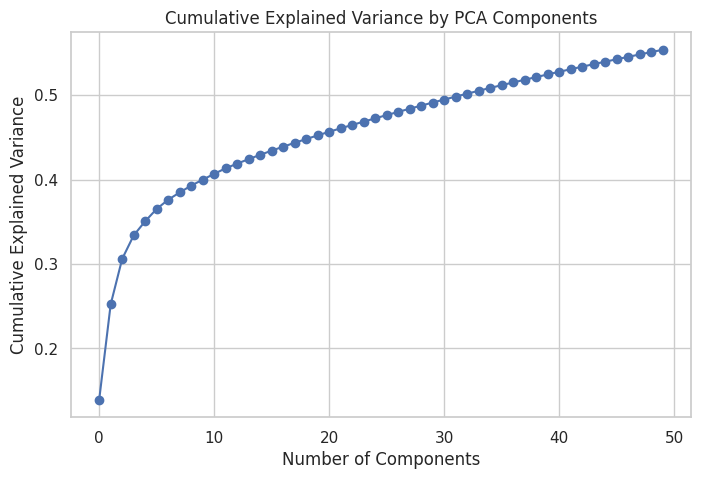

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

# Baseline Model Training

This section trains the six required models before hyperparameter tuning. These baseline results give a comparison point for the tuned models.

Models used:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Support Vector Machine
5. Random Forest
6. XGBoost

## 17. Train Baseline Models

PCA-transformed data is used for Logistic Regression, KNN, and SVM. Original feature data is used for Decision Tree, Random Forest, and XGBoost.

In [ ]:
# 1. Logistic Regression
log_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_model.fit(X_train_pca, y_train)

# 2. KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_pca, y_train)

# 3. Decision Tree
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)

# 4. SVM
svm_model = SVC(kernel="rbf", random_state=RANDOM_STATE)
svm_model.fit(X_train_pca, y_train)

# 5. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 6. XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

print("All six baseline models trained successfully.")

All six baseline models trained successfully.


## 18. Evaluate Baseline Models

The models are evaluated using Accuracy, Precision, Recall, and F1-score.

F1-score is especially important because the class distribution is not perfectly balanced. Accuracy alone can be misleading when one class is more common than the other.

In [ ]:
baseline_models = {
    "Logistic Regression": (log_model, X_test_pca),
    "KNN": (knn_model, X_test_pca),
    "Decision Tree": (dt_model, X_test),
    "SVM": (svm_model, X_test_pca),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test)
}

baseline_results = []

for name, (model, X_eval) in baseline_models.items():
    y_pred = model.predict(X_eval)
    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

baseline_results_df = pd.DataFrame(baseline_results).sort_values("F1", ascending=False)
baseline_results_df

,Model,Accuracy,Precision,Recall,F1
3,SVM,0.917141,0.856015,0.950561,0.900814
5,XGBoost,0.905552,0.851888,0.921634,0.885389
0,Logistic Regression,0.902706,0.873827,0.881487,0.877640
1,KNN,0.895836,0.839225,0.911466,0.873855
4,Random Forest,0.860583,0.812659,0.841865,0.827004
2,Decision Tree,0.809993,0.800324,0.692847,0.742718


## 19. Visualize Baseline Model Performance

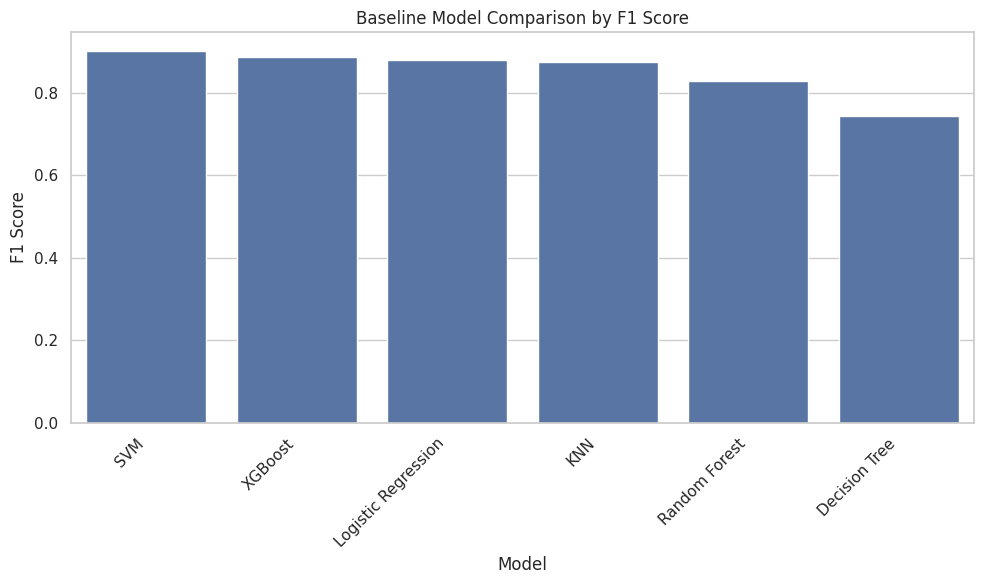

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=baseline_results_df, x="Model", y="F1")
plt.title("Baseline Model Comparison by F1 Score")
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

## 20. Confusion Matrices for All Baseline Models

A confusion matrix is required because this is a classification task.

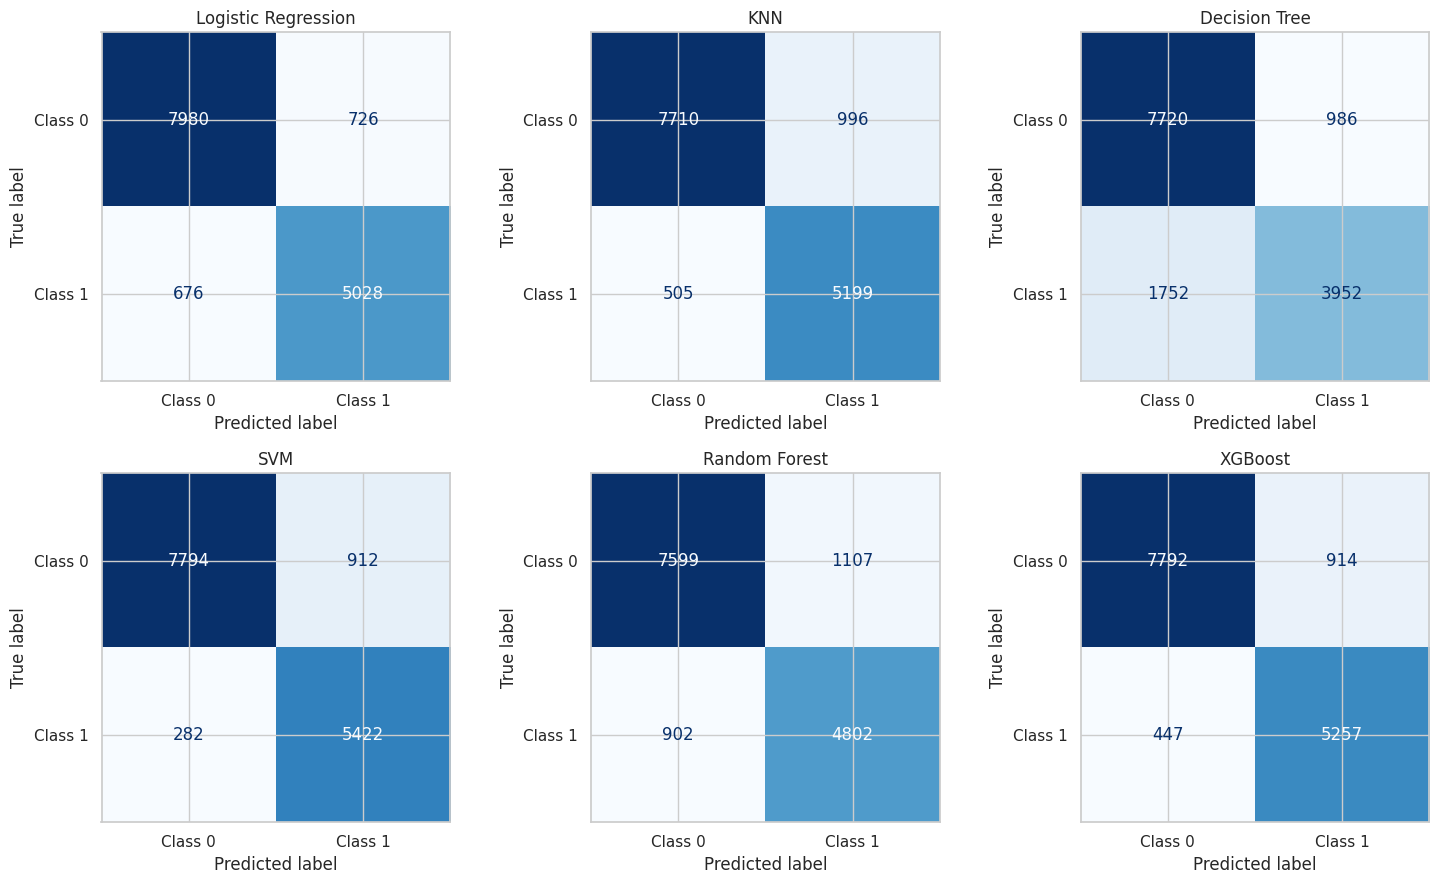

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, (model, X_eval)) in zip(axes, baseline_models.items()):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

# Hyperparameter Tuning with Cross-Validation

This section tunes the six models using a systematic cross-validation approach. The tuning is performed on the training data only. The held-out test set is used only for final evaluation.

To keep runtime manageable in Google Colab, a stratified sample of the training set is used for tuning. This still uses cross-validation and avoids tuning directly on the test set.

## 21. Create a Stratified Tuning Sample

This makes tuning faster on a large dataset. Increase `TUNE_SAMPLE_SIZE` if Colab runtime allows.

In [ ]:
TUNE_SAMPLE_SIZE = min(10000, len(X_train))

# Sample from the training set only
train_indices = y_train.groupby(y_train).sample(
    n=min(y_train.value_counts().min(), TUNE_SAMPLE_SIZE // y_train.nunique()),
    random_state=RANDOM_STATE
).index

X_train_tune = X_train.loc[train_indices]
y_train_tune = y_train.loc[train_indices]

# Create matching scaled/PCA tuning versions
X_train_tune_scaled = scaler.transform(X_train_tune)
X_train_tune_pca = pca.transform(X_train_tune_scaled)

print("Tuning sample X:", X_train_tune.shape)
print("Tuning sample y distribution:\n", y_train_tune.value_counts())

Tuning sample X: (10000, 2400)
Tuning sample y distribution:
 Class
0    5000
1    5000
Name: count, dtype: int64


## 22. Define Hyperparameter Grids

In [ ]:
log_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

dt_param_grid = {
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

rf_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

xgb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

## 23. Tune Logistic Regression with GridSearchCV

In [ ]:
log_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    log_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

log_grid.fit(X_train_tune_pca, y_train_tune)
best_log = log_grid.best_estimator_
print("Best Logistic Regression parameters:", log_grid.best_params_)

Best Logistic Regression parameters: {'C': 0.01, 'solver': 'liblinear'}


## 24. Tune KNN with GridSearchCV

In [ ]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train_tune_pca, y_train_tune)
best_knn = knn_grid.best_estimator_
print("Best KNN parameters:", knn_grid.best_params_)

Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}


## 25. Tune Decision Tree with GridSearchCV

In [ ]:

dt_param_grid = {
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train_tune, y_train_tune)
best_dt = dt_grid.best_estimator_
print("Best Decision Tree parameters:", dt_grid.best_params_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Decision Tree parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


## 26. Tune SVM with GridSearchCV

SVM can be slow on large datasets, so this uses the PCA tuning sample.

In [ ]:
svm_grid = GridSearchCV(
    SVC(random_state=RANDOM_STATE),
    svm_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train_tune_pca, y_train_tune)
best_svm = svm_grid.best_estimator_
print("Best SVM parameters:", svm_grid.best_params_)

Best SVM parameters: {'C': 1, 'kernel': 'rbf'}


## 27. Tune Random Forest with RandomizedSearchCV

RandomizedSearchCV is used to reduce runtime while still performing systematic cross-validated hyperparameter tuning.

In [ ]:
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_random.fit(X_train_tune, y_train_tune)
best_rf = rf_random.best_estimator_
print("Best Random Forest parameters:", rf_random.best_params_)

Best Random Forest parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}


## 28. Tune XGBoost with RandomizedSearchCV

In [ ]:
xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    xgb_param_dist,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_random.fit(X_train_tune, y_train_tune)
best_xgb = xgb_random.best_estimator_
print("Best XGBoost parameters:", xgb_random.best_params_)

Best XGBoost parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


# Final Evaluation of Tuned Models

The tuned models are evaluated on the held-out test set using Accuracy, Precision, Recall, and F1-score.

## 29. Evaluate Tuned Models on the Held-Out Test Set

In [ ]:
tuned_models = {
    "Logistic Regression": (best_log, X_test_pca),
    "KNN": (best_knn, X_test_pca),
    "Decision Tree": (best_dt, X_test),
    "SVM": (best_svm, X_test_pca),
    "Random Forest": (best_rf, X_test),
    "XGBoost": (best_xgb, X_test)
}

tuned_results = []

for name, (model, X_eval) in tuned_models.items():
    y_pred = model.predict(X_eval)
    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values("F1", ascending=False)
tuned_results_df

,Model,Accuracy,Precision,Recall,F1
3,SVM,0.916933,0.856510,0.949158,0.900457
5,XGBoost,0.909160,0.842877,0.947055,0.891934
4,Random Forest,0.908050,0.843991,0.941795,0.890215
2,Decision Tree,0.908397,0.856075,0.923913,0.888702
1,KNN,0.905066,0.833436,0.950035,0.887924
0,Logistic Regression,0.904372,0.849096,0.922335,0.884202


## 30. Baseline vs Tuned Model Comparison

In [ ]:
comparison_df = baseline_results_df.merge(
    tuned_results_df,
    on="Model",
    suffixes=("_Baseline", "_Tuned")
)

comparison_df

,Model,Accuracy_Baseline,Precision_Baseline,Recall_Baseline,F1_Baseline,Accuracy_Tuned,Precision_Tuned,Recall_Tuned,F1_Tuned
0,SVM,0.917141,0.856015,0.950561,0.900814,0.916933,0.856510,0.949158,0.900457
1,XGBoost,0.905552,0.851888,0.921634,0.885389,0.909160,0.842877,0.947055,0.891934
2,Logistic Regression,0.902706,0.873827,0.881487,0.877640,0.904372,0.849096,0.922335,0.884202
3,KNN,0.895836,0.839225,0.911466,0.873855,0.905066,0.833436,0.950035,0.887924
4,Random Forest,0.860583,0.812659,0.841865,0.827004,0.908050,0.843991,0.941795,0.890215
5,Decision Tree,0.809993,0.800324,0.692847,0.742718,0.908397,0.856075,0.923913,0.888702


## 31. Visualize Tuned Model Performance

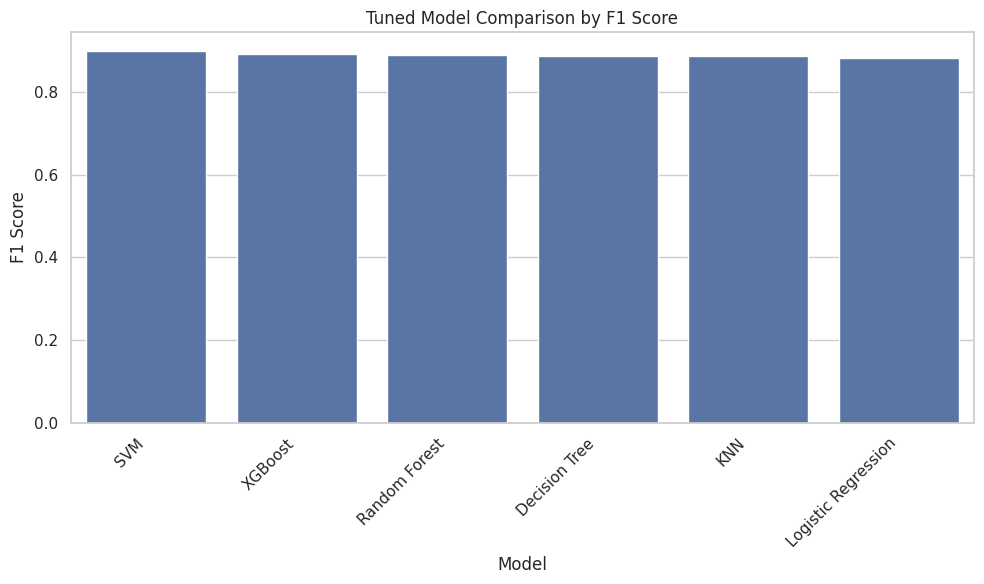

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=tuned_results_df, x="Model", y="F1")
plt.title("Tuned Model Comparison by F1 Score")
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

## 32. Confusion Matrices for All Tuned Models

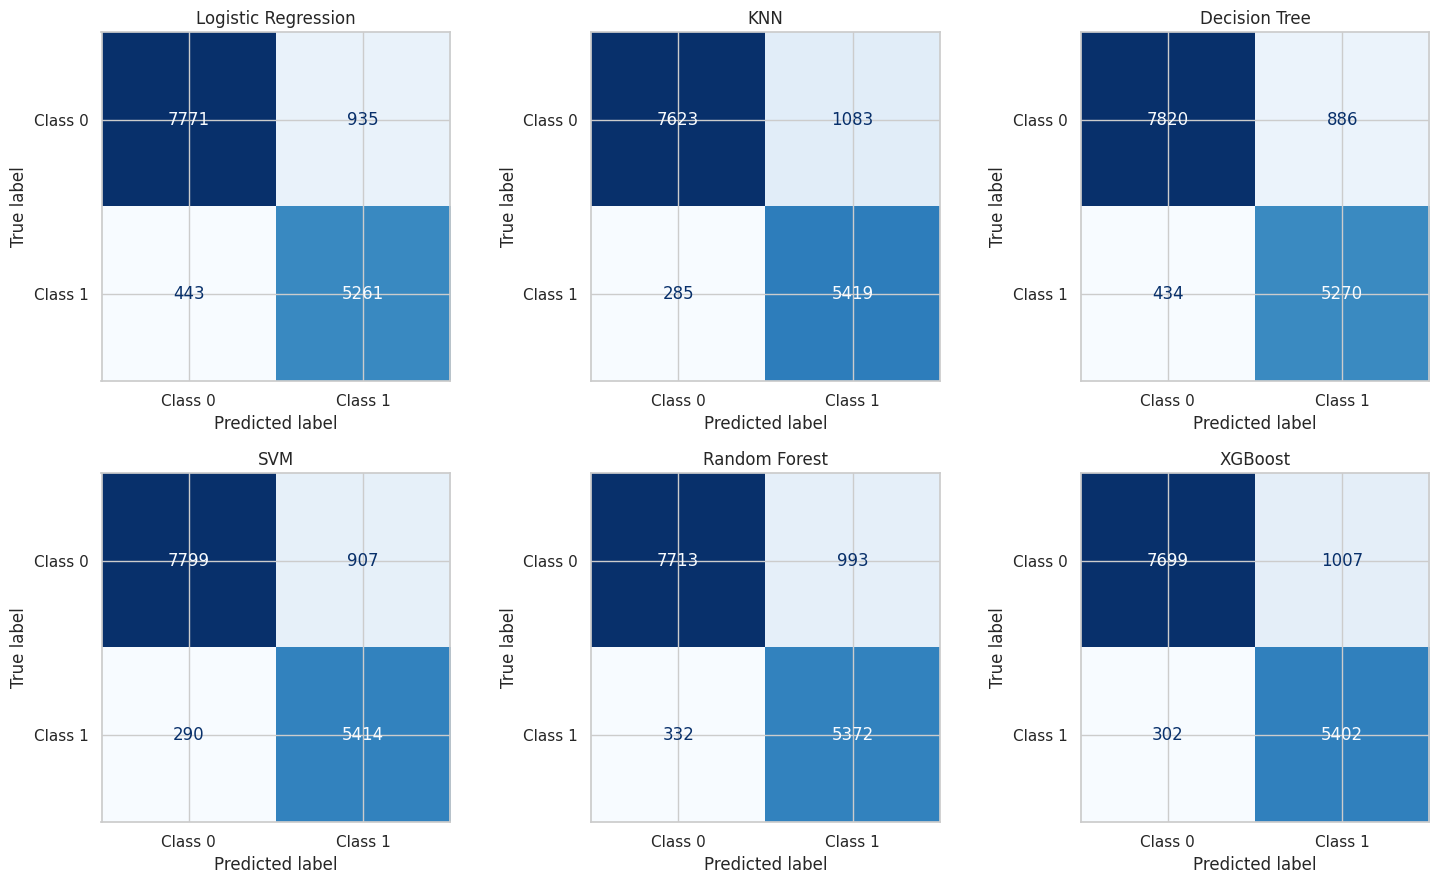

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, (model, X_eval)) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 33. Best Tuned Model and Classification Report

In [ ]:
best_model_name = tuned_results_df.loc[tuned_results_df["F1"].idxmax(), "Model"]
best_model, best_X_test = tuned_models[best_model_name]

y_pred_best = best_model.predict(best_X_test)

print("Best tuned model based on F1-score:", best_model_name)
print(classification_report(y_test, y_pred_best))

Best tuned model based on F1-score: SVM
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      8706
           1       0.86      0.95      0.90      5704

    accuracy                           0.92     14410
   macro avg       0.91      0.92      0.91     14410
weighted avg       0.92      0.92      0.92     14410



## 34. Confusion Matrix for the Best Tuned Model

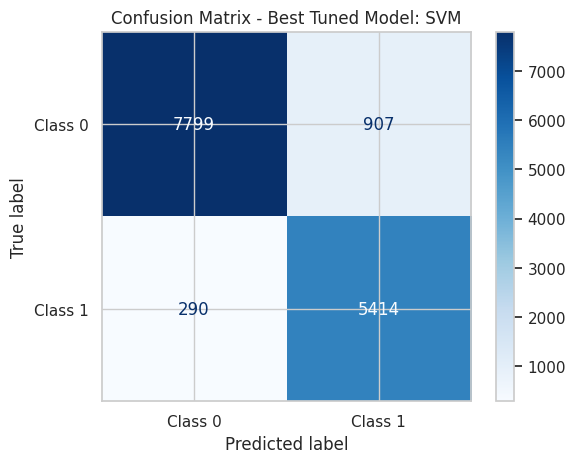

In [ ]:
cm_best = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - Best Tuned Model: {best_model_name}")
plt.show()

## 35. Feature Importance for Tree-Based Models

Feature importance is shown for the best available tree-based model. This helps explain which swarm features contributed most to classification.

In [ ]:
# Prefer tuned Random Forest for feature importance
importance_model = best_rf

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance_model.feature_importances_
}).sort_values("Importance", ascending=False)

top_features = importance_df.head(10)

top_features

,Feature,Importance
1683,yVel141,0.018011
452,xC38,0.016497
1131,yVel95,0.015878
1563,yVel131,0.014228
699,yVel59,0.013727
447,yVel38,0.012952
1377,yC115,0.012063
1431,yVel120,0.011774
1815,yVel152,0.011647
1935,yVel162,0.010767


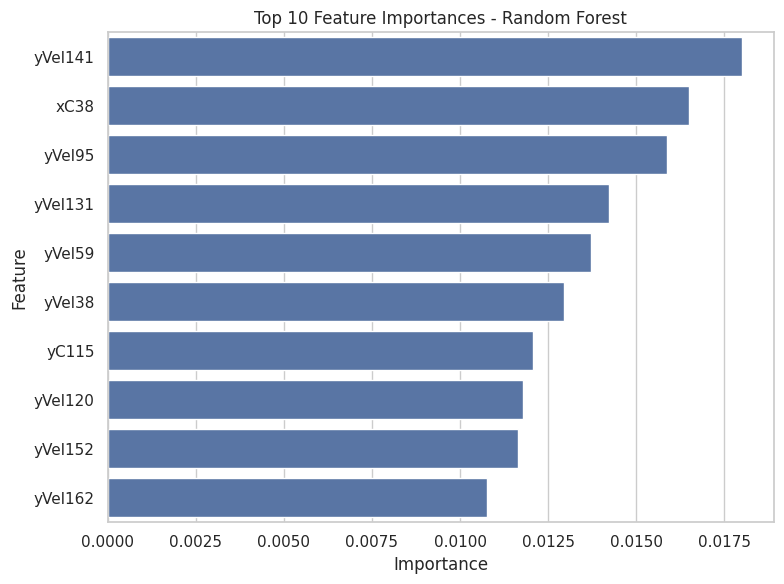

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()